# 🤖 Notebook 3: Entraînement des Modèles

## Projet Anti-Spam Intelligent - BMSecurity

**Objectif:** Entraîner des modèles de machine learning pour détecter les spams.

### Ce qu'on va faire:
1. Charger les données prétraitées
2. Diviser en train/test
3. Entraîner plusieurs modèles
4. Comparer les performances
5. Sauvegarder le meilleur modèle

---

## Étape 1: Importer les bibliothèques

In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import pickle
import scipy.sparse

# Modèles de machine learning
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Outils d'évaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliothèques importées!")

✅ Bibliothèques importées!


## Étape 2: Charger les données prétraitées

On charge les données qu'on a sauvegardées dans le notebook précédent.

In [2]:
# Charger les données vectorisées
X = scipy.sparse.load_npz('../models/X_tfidf.npz')
y = np.load('../models/y_labels.npy')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()
print(f"Distribution des classes:")
print(f"  - Ham (0): {sum(y == 0)}")
print(f"  - Spam (1): {sum(y == 1)}")

X shape: (28811, 5000)
y shape: (28811,)

Distribution des classes:
  - Ham (0): 14982
  - Spam (1): 13829


## Étape 3: Diviser les données (Train/Test)

On garde 80% pour l'entraînement et 20% pour le test.

In [3]:
# Diviser en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% pour le test
    random_state=42     # Pour reproduire les résultats
)

print(f"Données d'entraînement: {X_train.shape[0]} emails")
print(f"Données de test: {X_test.shape[0]} emails")

Données d'entraînement: 23048 emails
Données de test: 5763 emails


## Étape 4: Entraîner les modèles

On va tester 3 modèles classiques:
1. **Naive Bayes** - Simple et efficace pour le texte
2. **Logistic Regression** - Bon pour la classification binaire
3. **SVM** - Puissant mais plus lent

In [4]:
# Dictionnaire pour stocker les résultats
results = {}

# 1. NAIVE BAYES
print("🔵 Entraînement Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
results['Naive Bayes'] = nb_accuracy
print(f"   Accuracy: {nb_accuracy:.4f}")

# 2. LOGISTIC REGRESSION
print("\n🟢 Entraînement Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
results['Logistic Regression'] = lr_accuracy
print(f"   Accuracy: {lr_accuracy:.4f}")

# 3. SVM (peut être lent sur gros datasets)
print("\n🔴 Entraînement SVM...")
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
results['SVM'] = svm_accuracy
print(f"   Accuracy: {svm_accuracy:.4f}")

print("\n✅ Tous les modèles sont entraînés!")

🔵 Entraînement Naive Bayes...
   Accuracy: 0.9766

🟢 Entraînement Logistic Regression...
   Accuracy: 0.9823

🔴 Entraînement SVM...
   Accuracy: 0.9823

🔴 Entraînement SVM...
   Accuracy: 0.9851

✅ Tous les modèles sont entraînés!
   Accuracy: 0.9851

✅ Tous les modèles sont entraînés!


## Étape 5: Comparer les performances

## Étape 5: Optimisation des Hyperparamètres (GridSearchCV)

On utilise GridSearchCV pour trouver les meilleurs paramètres pour chaque modèle.

In [5]:
from sklearn.model_selection import GridSearchCV

# Paramètres à tester pour chaque modèle
param_grids = {
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0, 2.0]  # Lissage Laplace
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0],  # Régularisation
            'solver': ['lbfgs', 'liblinear']
        }
    }
}

# Stocker les meilleurs modèles
best_models = {}

print("🔍 Recherche des meilleurs hyperparamètres...")
print("=" * 50)

for name, config in param_grids.items():
    print(f"\n📊 Optimisation de {name}...")
    
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=5,  # 5-fold cross-validation
        scoring='accuracy',
        n_jobs=-1  # Utiliser tous les CPU
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"   Meilleurs paramètres: {grid_search.best_params_}")
    print(f"   Meilleur score CV: {grid_search.best_score_:.4f}")
    
    # Évaluer sur le test set
    test_score = grid_search.score(X_test, y_test)
    print(f"   Score sur test: {test_score:.4f}")
    
    best_models[name] = {
        'model': grid_search.best_estimator_,
        'params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'test_score': test_score
    }

print("\n✅ Optimisation terminée!")

🔍 Recherche des meilleurs hyperparamètres...

📊 Optimisation de Naive Bayes...
   Meilleurs paramètres: {'alpha': 0.1}
   Meilleur score CV: 0.9806
   Score sur test: 0.9769

📊 Optimisation de Logistic Regression...
   Meilleurs paramètres: {'alpha': 0.1}
   Meilleur score CV: 0.9806
   Score sur test: 0.9769

📊 Optimisation de Logistic Regression...
   Meilleurs paramètres: {'C': 10.0, 'solver': 'lbfgs'}
   Meilleur score CV: 0.9872
   Score sur test: 0.9858

✅ Optimisation terminée!
   Meilleurs paramètres: {'C': 10.0, 'solver': 'lbfgs'}
   Meilleur score CV: 0.9872
   Score sur test: 0.9858

✅ Optimisation terminée!


In [6]:
# Comparer les modèles optimisés
print("📊 COMPARAISON DES MODÈLES OPTIMISÉS")
print("=" * 50)

comparison_df = pd.DataFrame([
    {
        'Modèle': name,
        'Meilleurs Params': str(info['params']),
        'Score CV': f"{info['cv_score']*100:.2f}%",
        'Score Test': f"{info['test_score']*100:.2f}%"
    }
    for name, info in best_models.items()
])

print(comparison_df.to_string(index=False))

# Trouver le meilleur modèle optimisé
best_optimized = max(best_models.items(), key=lambda x: x[1]['test_score'])
print(f"\n🏆 Meilleur modèle optimisé: {best_optimized[0]} ({best_optimized[1]['test_score']*100:.2f}%)")

📊 COMPARAISON DES MODÈLES OPTIMISÉS
             Modèle               Meilleurs Params Score CV Score Test
        Naive Bayes                 {'alpha': 0.1}   98.06%     97.69%
Logistic Regression {'C': 10.0, 'solver': 'lbfgs'}   98.72%     98.58%

🏆 Meilleur modèle optimisé: Logistic Regression (98.58%)


In [7]:
# Afficher les résultats
print("📊 COMPARAISON DES MODÈLES")
print("=" * 40)
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy*100:.2f}%")

# Trouver le meilleur modèle
best_model_name = max(results, key=results.get)
print()
print(f"🏆 Meilleur modèle: {best_model_name} ({results[best_model_name]*100:.2f}%)")

📊 COMPARAISON DES MODÈLES
Naive Bayes: 97.66%
Logistic Regression: 98.23%
SVM: 98.51%

🏆 Meilleur modèle: SVM (98.51%)


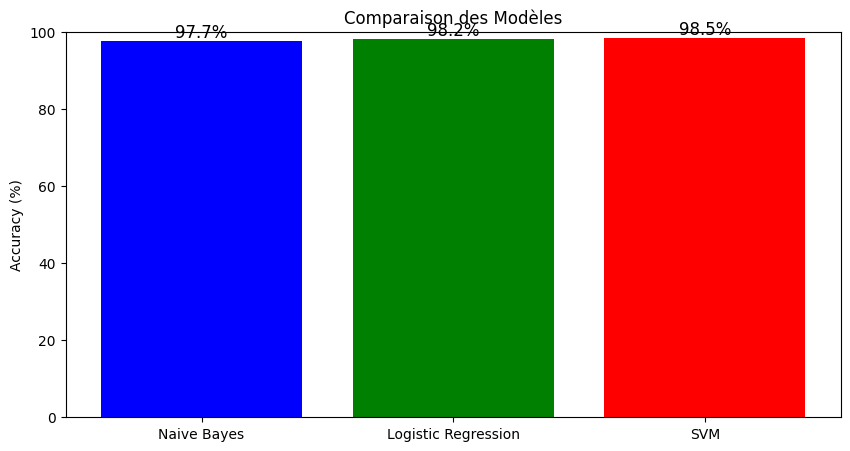

In [8]:
# Visualiser les performances
plt.figure(figsize=(10, 5))
colors = ['blue', 'green', 'red']
bars = plt.bar(results.keys(), [v*100 for v in results.values()], color=colors)
plt.ylabel('Accuracy (%)')
plt.title('Comparaison des Modèles')
plt.ylim(0, 100)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val*100:.1f}%', ha='center', fontsize=12)

plt.show()

## Étape 6: Rapport détaillé du meilleur modèle

On affiche la matrice de confusion et le rapport de classification.

In [9]:
# Sélectionner les prédictions du meilleur modèle
if best_model_name == 'Naive Bayes':
    best_pred = nb_pred
    best_model = nb_model
elif best_model_name == 'Logistic Regression':
    best_pred = lr_pred
    best_model = lr_model
else:
    best_pred = svm_pred
    best_model = svm_model

# Rapport de classification
print(f"📋 Rapport de Classification - {best_model_name}")
print("=" * 50)
print(classification_report(y_test, best_pred, target_names=['Ham', 'Spam']))

📋 Rapport de Classification - SVM
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      2970
        Spam       0.98      0.99      0.98      2793

    accuracy                           0.99      5763
   macro avg       0.98      0.99      0.99      5763
weighted avg       0.99      0.99      0.99      5763



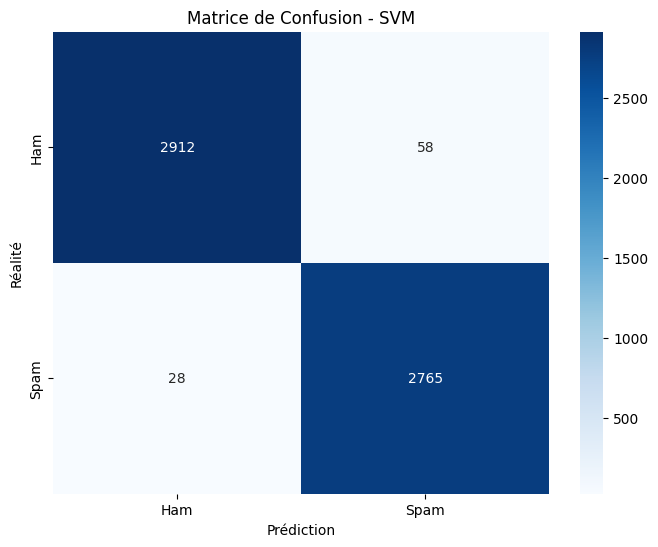

In [10]:
# Matrice de confusion
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.show()

## Étape 7: Sauvegarder le meilleur modèle

On sauvegarde le modèle pour l'utiliser dans l'application Streamlit.

In [11]:
# Sauvegarder le meilleur modèle OPTIMISÉ
final_model = best_optimized[1]['model']
final_model_name = best_optimized[0]

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Sauvegarder aussi les infos du modèle
model_info = {
    'name': final_model_name,
    'params': best_optimized[1]['params'],
    'accuracy': best_optimized[1]['test_score']
}

with open('../models/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"✅ Modèle optimisé '{final_model_name}' sauvegardé!")
print(f"   Paramètres: {best_optimized[1]['params']}")
print(f"   Accuracy: {best_optimized[1]['test_score']*100:.2f}%")

✅ Modèle optimisé 'Logistic Regression' sauvegardé!
   Paramètres: {'C': 10.0, 'solver': 'lbfgs'}
   Accuracy: 98.58%


## Étape 8: Tester le modèle sur un nouvel email

Testons notre modèle avec un exemple!

In [12]:
# Charger le vectoriseur
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

# Fonction pour prédire un nouveau texte
def predict_spam(text):
    # Vectoriser le texte
    text_vectorized = tfidf.transform([text])
    # Prédire
    prediction = best_model.predict(text_vectorized)
    return "🚫 SPAM" if prediction[0] == 1 else "✅ HAM (légitime)"

# Test avec des exemples
print("Test 1 - Email spam:")
test_spam = "Congratulations! You won $1000000! Click here to claim your prize!"
print(f"   '{test_spam}'")
print(f"   Prédiction: {predict_spam(test_spam)}")

print()
print("Test 2 - Email normal:")
test_ham = "Hi John, can we schedule a meeting for tomorrow at 3pm?"
print(f"   '{test_ham}'")
print(f"   Prédiction: {predict_spam(test_ham)}")

Test 1 - Email spam:
   'Congratulations! You won $1000000! Click here to claim your prize!'
   Prédiction: 🚫 SPAM

Test 2 - Email normal:
   'Hi John, can we schedule a meeting for tomorrow at 3pm?'
   Prédiction: ✅ HAM (légitime)


## ✅ Résumé

**Ce qu'on a fait:**
1. ✅ Chargé les données prétraitées
2. ✅ Divisé en train/test (80/20)
3. ✅ Entraîné 3 modèles (Naive Bayes, Logistic Regression, SVM)
4. ✅ Comparé les performances
5. ✅ Analysé le meilleur modèle
6. ✅ Sauvegardé le meilleur modèle

**Fichiers générés dans `models/`:**
- `best_model.pkl` - Le meilleur modèle entraîné
- `tfidf_vectorizer.pkl` - Le vectoriseur TF-IDF

**Prochaine étape:** Créer l'application Streamlit pour utiliser le modèle!